In [1]:
#  Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

In [3]:
# Data Load

In [4]:
df = pd.read_csv("../data/Country-data.csv")
print("Shape:", df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
# Check  Missing values check

In [6]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
Duplicates: 0


In [7]:
# Histograms 

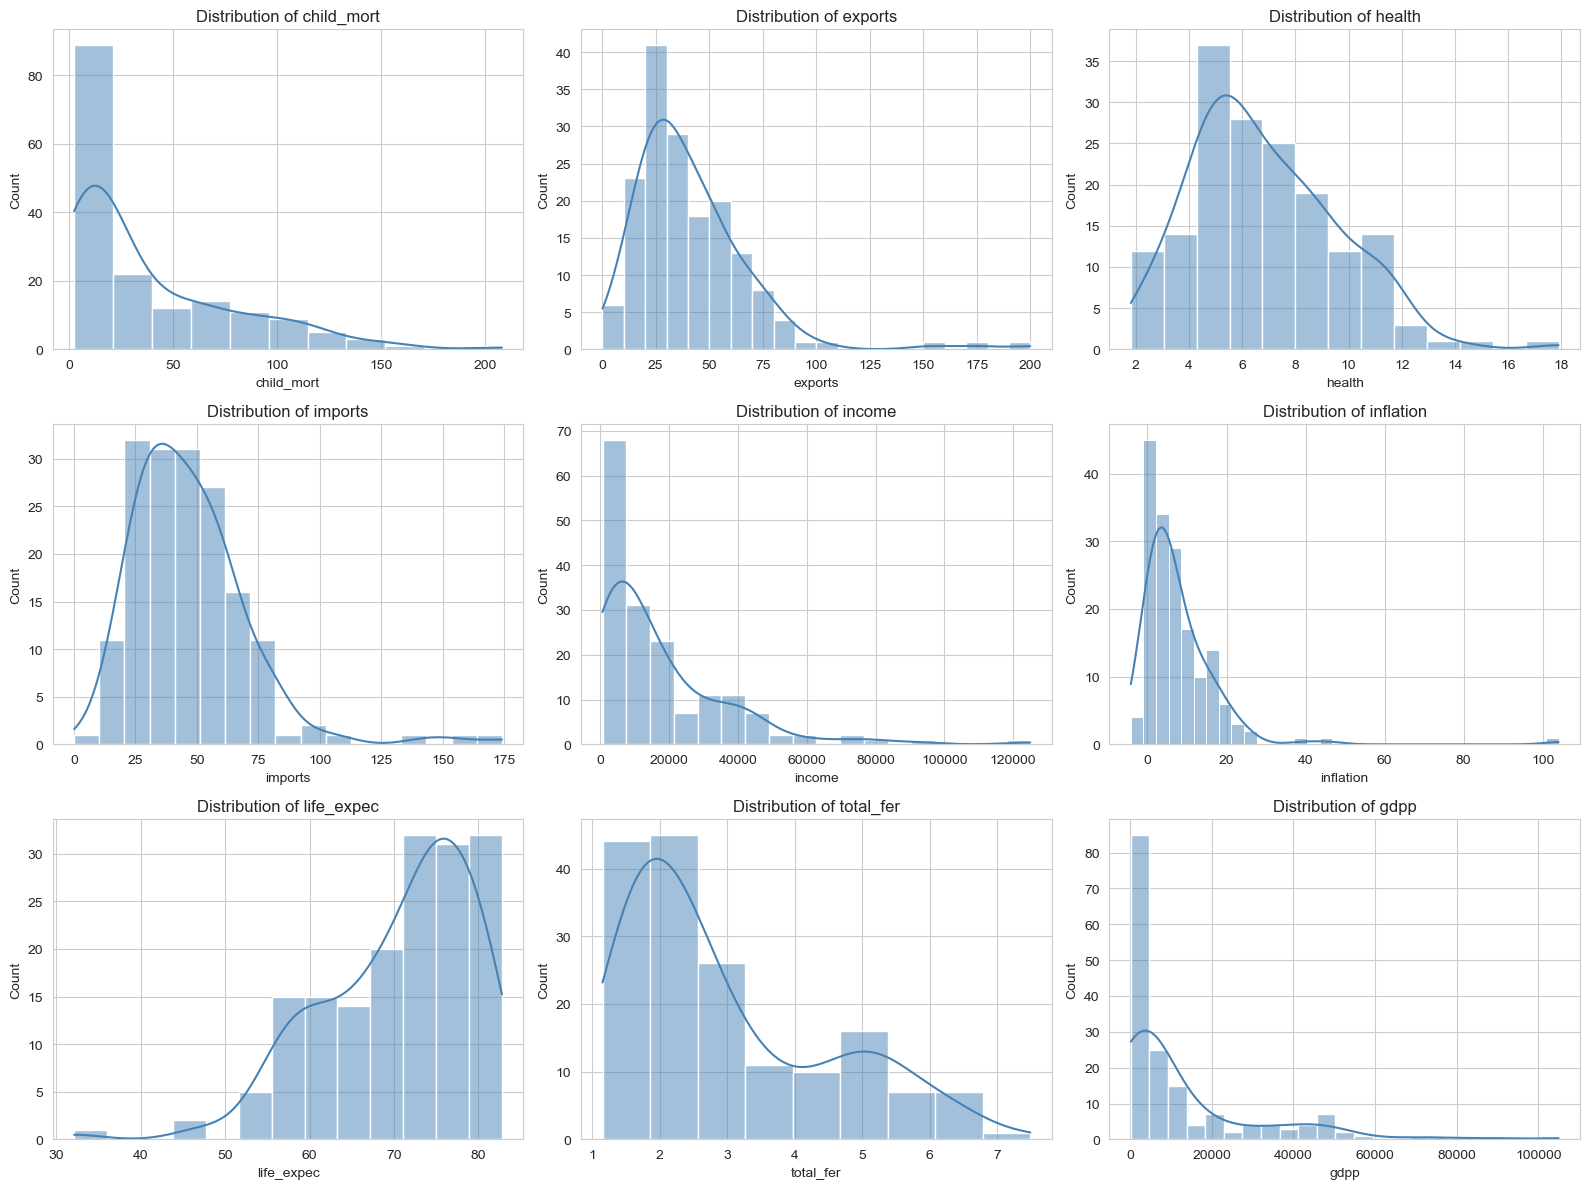

In [8]:
numeric_cols = df.columns.drop('country')

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="steelblue")
    axes[i].set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("../images/histograms.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Boxplots

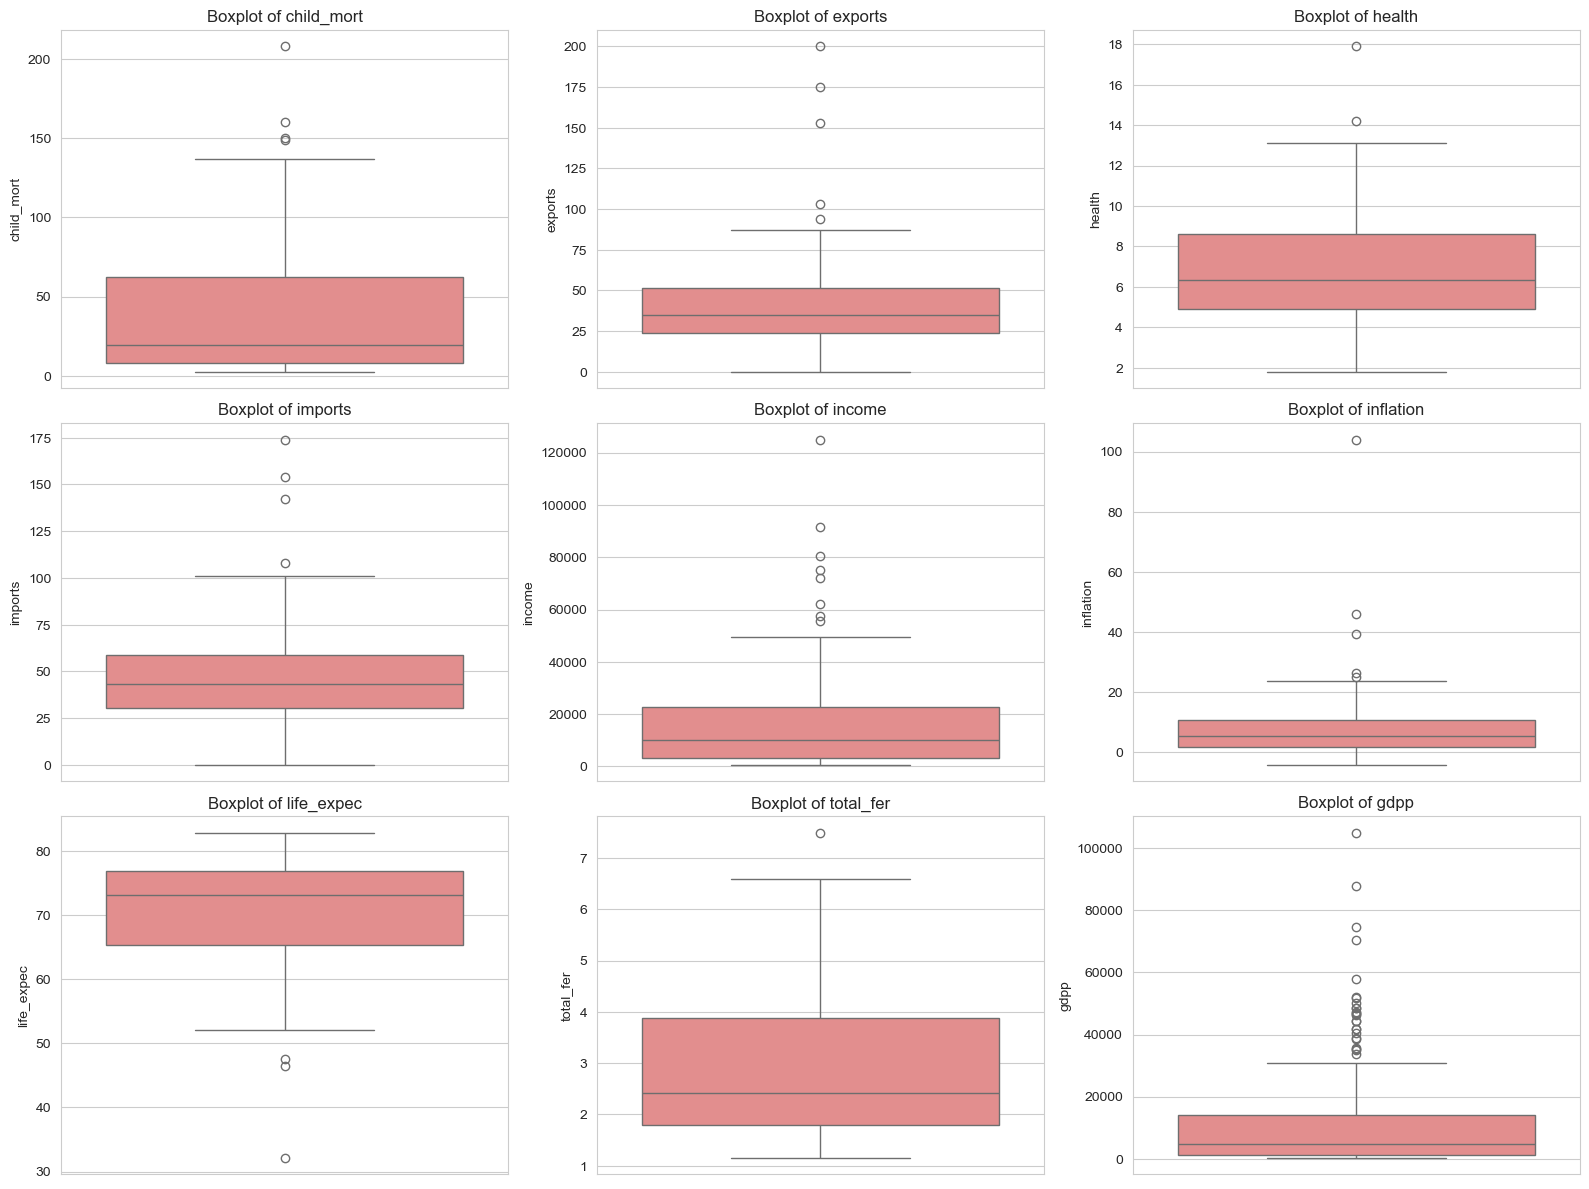

In [10]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.savefig("../images/boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
#  Correlation Heatmap

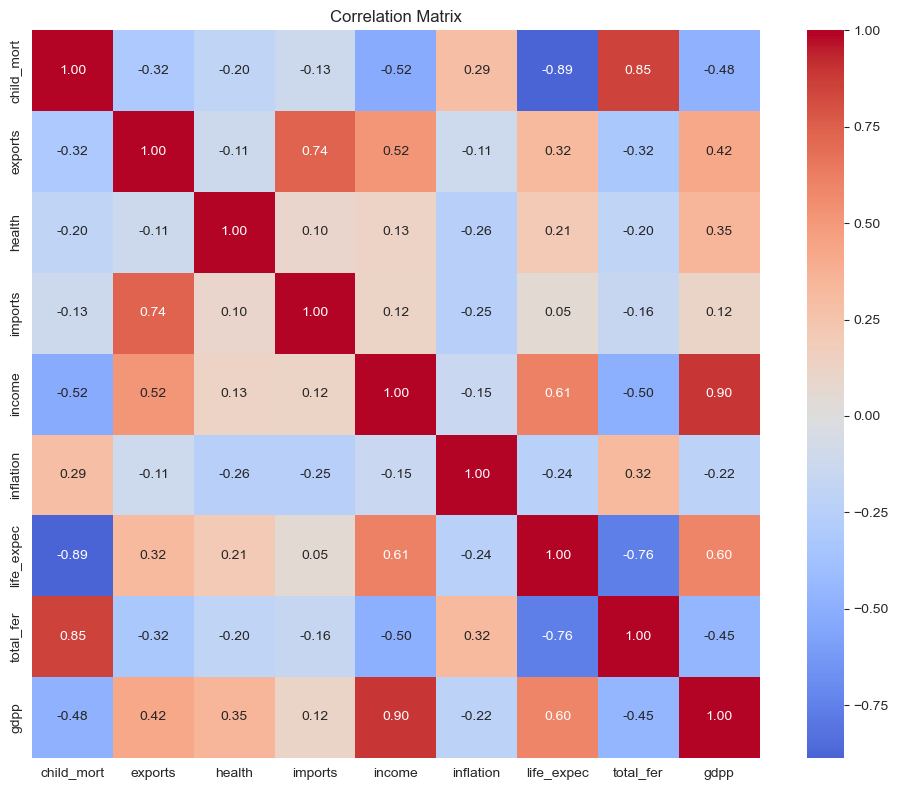

In [12]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("../images/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
# Preprocessing 

In [14]:
countries = df['country'].copy()
X = df.drop(columns=['country']).copy()

# Skewed features ko log transform karo
skewness = X.skew()
skewed_features = skewness[abs(skewness) > 1].index.tolist()
skewed_features = [f for f in skewed_features if (X[f] >= 0).all()]

X_transformed = X.copy()
for feat in skewed_features:
    X_transformed[feat] = np.log1p(X_transformed[feat])

# Standard scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_transformed), columns=X.columns)
X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.278012,-1.764313,0.279088,0.147868,-1.413035,0.157336,-1.619092,1.902882,-1.460301
1,-0.239708,-0.283872,-0.097016,0.291835,0.071660,-0.312347,0.647866,-0.859973,-0.122835
2,0.198464,0.184161,-0.966073,-0.498946,0.285240,0.789274,0.670423,-0.038404,-0.064916
3,1.531191,0.908223,-1.448071,0.065136,-0.353257,1.387054,-1.179234,2.128151,-0.221309
4,-0.648481,0.437193,-0.286894,0.642228,0.605586,-0.601749,0.704258,-0.541946,0.608135


In [15]:
 # k-Distance Graph 

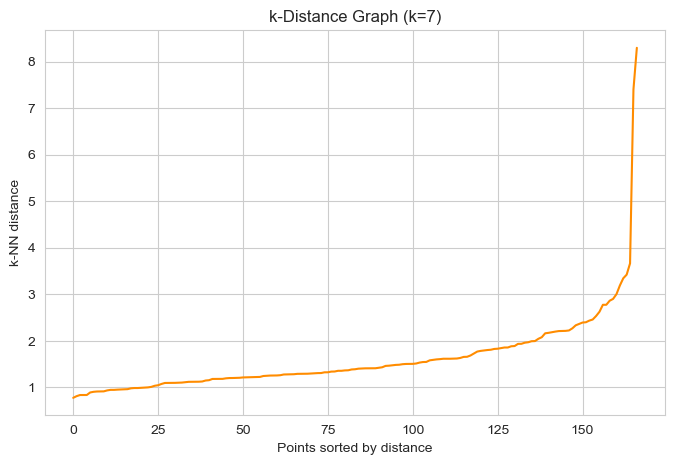

In [16]:
neighbors = NearestNeighbors(n_neighbors=7)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(k_distances, color="darkorange")
plt.xlabel("Points sorted by distance")
plt.ylabel("k-NN distance")
plt.title("k-Distance Graph (k=7)")
plt.savefig("../images/k_distance_graph.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
#  Grid Search 

In [18]:
eps_values = [1.0, 1.3, 1.5]
min_samples_values = [4, 6, 8]

results = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels = db.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        if n_clusters >= 2:
            mask = labels != -1
            sil = silhouette_score(X_scaled[mask], labels[mask]) if len(set(labels[mask]))>=2 else np.nan
        else:
            sil = np.nan
        results.append({"eps": eps, "min_samples": ms, "n_clusters": n_clusters,
                         "n_noise": n_noise, "silhouette": round(sil,4) if not np.isnan(sil) else np.nan})

results_df = pd.DataFrame(results)
results_df

,eps,min_samples,n_clusters,n_noise,silhouette
0,1.0,4,3,97,0.1886
1,1.0,6,2,121,0.4304
2,1.0,8,3,134,0.3638
3,1.3,4,2,43,0.4362
4,1.3,6,3,56,0.2539
5,1.3,8,2,68,0.5168
6,1.5,4,1,29,NaN
7,1.5,6,1,31,NaN
8,1.5,8,2,39,0.4407


In [19]:
#  Final DBSCAN

In [20]:
BEST_EPS = 1.5
BEST_MIN_SAMPLES = 8

dbscan_final = DBSCAN(eps=BEST_EPS, min_samples=BEST_MIN_SAMPLES)
cluster_labels = dbscan_final.fit_predict(X_scaled)

df_result = df.copy()
df_result['cluster'] = cluster_labels

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)
print("Clusters:", n_clusters)
print("Noise points:", n_noise)

mask = cluster_labels != -1
print("Silhouette Score:", silhouette_score(X_scaled[mask], cluster_labels[mask]))

Clusters: 2
Noise points: 39
Silhouette Score: 0.4407306513520882


In [21]:
for c in sorted(df_result['cluster'].unique()):
    if c == -1:
        continue
    members = df_result[df_result['cluster'] == c]['country'].tolist()
    print(f"Cluster {c} ({len(members)} countries):", members)
    print()

Cluster 0 (106 countries): ['Albania', 'Algeria', 'Antigua and Barbuda', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Brunei', 'Bulgaria', 'Cambodia', 'Canada', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Estonia', 'Fiji', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Grenada', 'Guatemala', 'Guyana', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Kyrgyz Republic', 'Lao', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Macedonia, FYR', 'Malaysia', 'Maldives', 'Mauritius', 'Moldova', 'Montenegro', 'Morocco', 'Namibia', 'Netherlands', 'New Zealand', 'Norway', 'Oman', 'Panama', 'Paraguay', 'Peru', 'Philippines', 'Poland', 'Portugal', 'Qatar', 'Roma

In [28]:
#  Noise / Outlier Countries

In [29]:
noise_countries = df_result[df_result['cluster'] == -1]
print(f"Noise countries ({len(noise_countries)}):")
noise_countries[['country','child_mort','income','life_expec','gdpp']]

Noise countries (39):


,country,child_mort,income,life_expec,gdpp
3,Angola,119.0,5900,60.1,3530
5,Argentina,14.5,18700,75.8,10300
21,Botswana,52.5,13300,57.1,6350
22,Brazil,19.8,14500,74.2,11200
26,Burundi,93.6,764,57.7,231
31,Central African Republic,149.0,888,47.5,446
37,"Congo, Dem. Rep.",116.0,609,57.5,334
38,"Congo, Rep.",63.9,5190,60.4,2740
49,Equatorial Guinea,111.0,33700,60.9,17100
50,Eritrea,55.2,1420,61.7,482


In [30]:
# PCA 2D Visualization

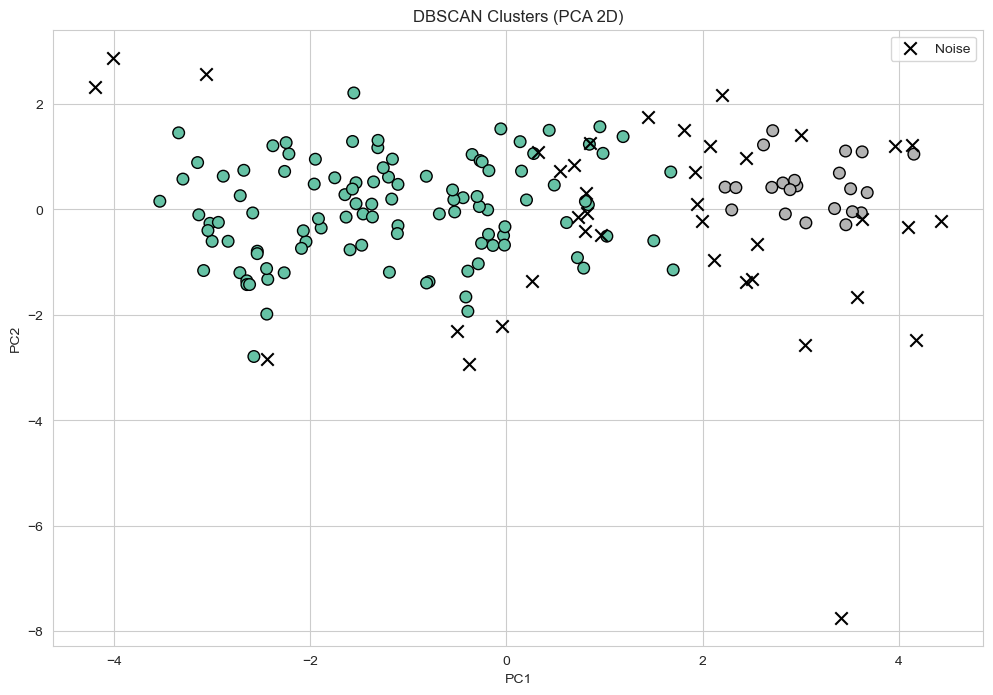

In [31]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
plt.scatter(X_pca[cluster_labels!=-1, 0], X_pca[cluster_labels!=-1, 1],
            c=cluster_labels[cluster_labels!=-1], cmap='Set2', s=70, edgecolors='k')
plt.scatter(X_pca[cluster_labels==-1, 0], X_pca[cluster_labels==-1, 1],
            c='black', marker='x', s=80, label='Noise')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters (PCA 2D)")
plt.legend()
plt.savefig("../images/pca_2d_clusters.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
#  Bar Chart — Avg Features per Cluster

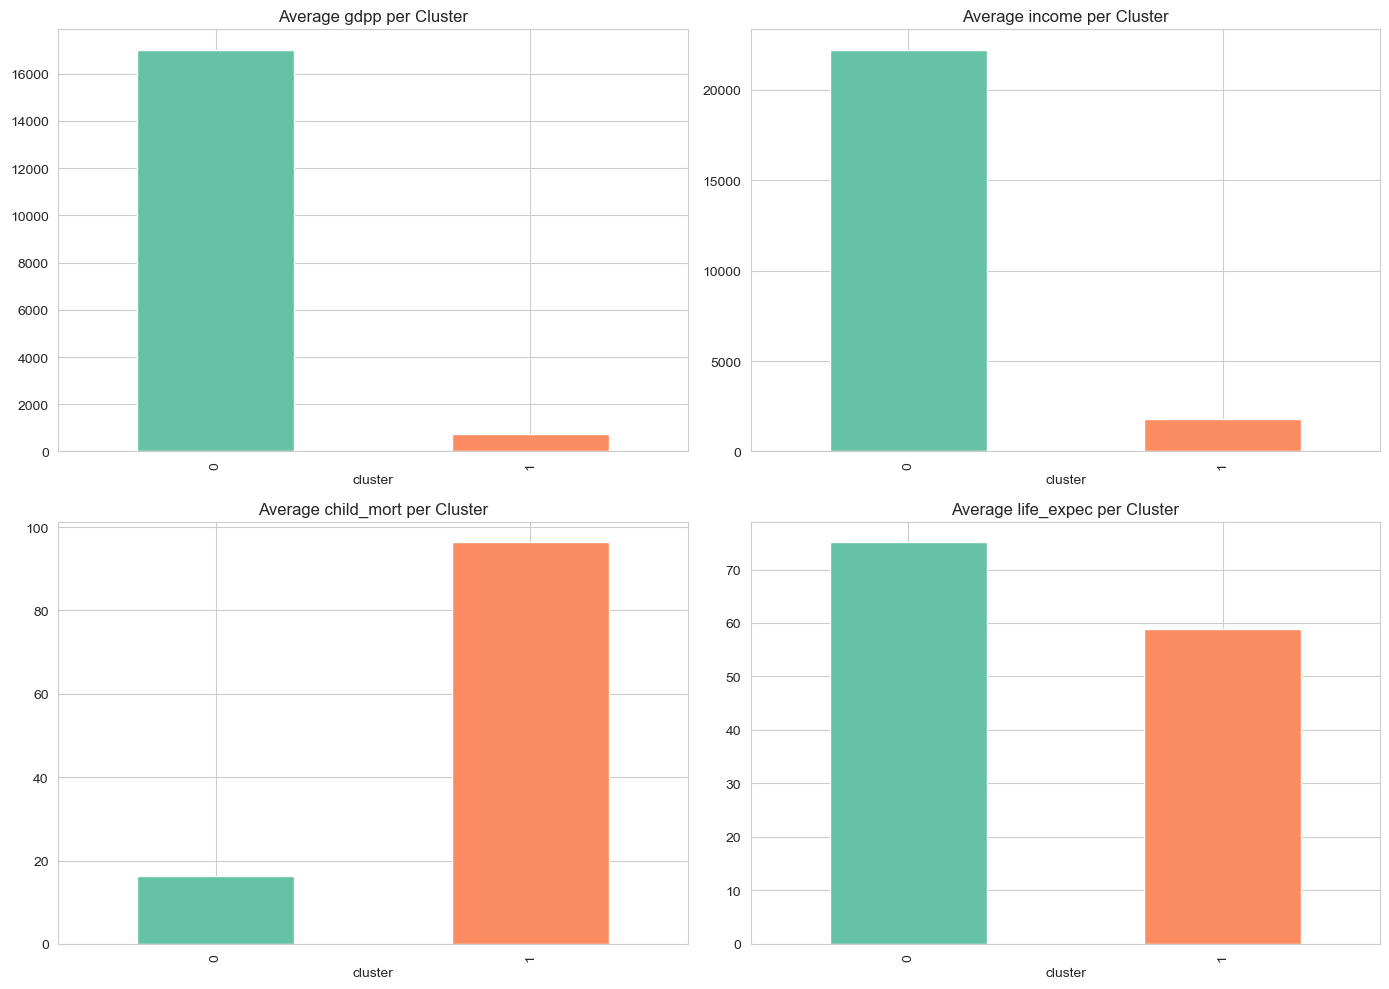

In [33]:
cluster_means = df_result[df_result['cluster']!=-1].groupby('cluster')[numeric_cols].mean()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, feat in enumerate(['gdpp','income','child_mort','life_expec']):
    cluster_means[feat].plot(kind='bar', ax=axes[i], color=['#66c2a5','#fc8d62'])
    axes[i].set_title(f"Average {feat} per Cluster")
plt.tight_layout()
plt.savefig("../images/cluster_bar_charts.png", dpi=150, bbox_inches="tight")
plt.show()

In [34]:
#  K-Means Comparison

In [35]:
for k in [3, 4]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_labels = km.fit_predict(X_scaled)
    print(f"K-Means (K={k}) -> Silhouette: {silhouette_score(X_scaled, km_labels):.4f}, "
          f"Davies-Bouldin: {davies_bouldin_score(X_scaled, km_labels):.4f}")

print(f"DBSCAN -> Silhouette: {silhouette_score(X_scaled[mask], cluster_labels[mask]):.4f}")

K-Means (K=3) -> Silhouette: 0.2482, Davies-Bouldin: 1.3683
K-Means (K=4) -> Silhouette: 0.2537, Davies-Bouldin: 1.0618
DBSCAN -> Silhouette: 0.4407
